# 🦓 Wildlife Classification — Colab Training Notebook

This notebook trains a 4-class wildlife image classifier for:
- buffalo
- elephant
- rhino
- zebra

It is designed for Google Colab with Google Drive as the ZIP source.

**Important:** The notebook uses a **stratified train/validation split** instead of `validation_split` from `image_dataset_from_directory`, preventing the previous issue where validation contained only one class.

Before training, the notebook verifies that all four classes are present.


## STEP 1 — Environment Check

In [1]:
# ============================================================
# STEP 1 — ENVIRONMENT CHECK
# ============================================================

import sys
import os
import json
import shutil
import zipfile
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image, UnidentifiedImageError

print("=" * 70)
print("WILDLIFE CLASSIFICATION — COLAB ENVIRONMENT")
print("=" * 70)

print("Python       :", sys.version.split()[0])
print("TensorFlow   :", tf.__version__)
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("Matplotlib   :", plt.matplotlib.__version__)
print("Seaborn      :", sns.__version__)
print("Pillow       :", Image.__version__)

print("\nGPU:")
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        print(gpu)
    print("\n✅ GPU AVAILABLE")
else:
    print("❌ GPU NOT AVAILABLE")
    print("Enable GPU in Runtime → Change runtime type → GPU")


WILDLIFE CLASSIFICATION — COLAB ENVIRONMENT
Python       : 3.12.13
TensorFlow   : 2.20.0
NumPy        : 2.0.2
Pandas       : 2.2.2
Matplotlib   : 3.10.0
Seaborn      : 0.13.2
Pillow       : 11.3.0

GPU:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✅ GPU AVAILABLE


## STEP 2 — GPU Configuration

In [2]:
# ============================================================
# STEP 2 — GPU CONFIGURATION
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print("GPU count:", len(gpus))
print("GPU devices:", gpus)


GPU count: 1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## STEP 3 — Mount Google Drive

In [3]:
# ============================================================
# STEP 3 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

print("✅ Google Drive mounted")


Mounted at /content/drive
✅ Google Drive mounted


## STEP 4 — Find ZIP Files

In [4]:
# ============================================================
# STEP 4 — FIND ZIP FILES
# ============================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")

zip_files = list(DRIVE_ROOT.rglob("*.zip"))

print("=" * 70)
print("ZIP FILES FOUND")
print("=" * 70)

if not zip_files:
    raise FileNotFoundError(
        "No ZIP files found in Google Drive."
    )

for i, file in enumerate(zip_files):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"[{i}] {file} — {size_mb:.2f} MB")


ZIP FILES FOUND
[0] /content/drive/MyDrive/wildlife.zip — 447.82 MB


## STEP 5 — Select Wildlife ZIP

If your wildlife ZIP is not the first file, change `ZIP_INDEX`.

In [5]:
# ============================================================
# STEP 5 — SELECT WILDLIFE ZIP
# ============================================================

ZIP_INDEX = 0

if ZIP_INDEX >= len(zip_files):
    raise IndexError(
        f"ZIP_INDEX {ZIP_INDEX} is invalid. "
        f"Choose a number from 0 to {len(zip_files)-1}."
    )

ZIP_PATH = zip_files[ZIP_INDEX]

print("Selected ZIP:")
print(ZIP_PATH)


Selected ZIP:
/content/drive/MyDrive/wildlife.zip


## STEP 6 — Extract Dataset

In [6]:
# ============================================================
# STEP 6 — EXTRACT DATASET
# ============================================================

EXTRACT_DIR = Path("/content/wildlife_dataset")

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Extracting dataset...")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("✅ Extraction completed")
print("Extracted to:", EXTRACT_DIR)


Extracting dataset...
✅ Extraction completed
Extracted to: /content/wildlife_dataset


## STEP 7 — Find Dataset Root

In [7]:
# ============================================================
# STEP 7 — FIND DATASET ROOT
# ============================================================

CLASS_NAMES = [
    "buffalo",
    "elephant",
    "rhino",
    "zebra"
]

NUM_CLASSES = len(CLASS_NAMES)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

def find_dataset_root(search_root, class_names):
    search_root = Path(search_root)
    required = set(name.lower() for name in class_names)

    candidates = [search_root] + [
        p for p in search_root.rglob("*")
        if p.is_dir()
    ]

    for folder in candidates:
        try:
            child_dirs = {
                p.name.lower()
                for p in folder.iterdir()
                if p.is_dir()
            }
        except PermissionError:
            continue

        if required.issubset(child_dirs):
            return folder

    return None


DATA_ROOT = find_dataset_root(
    EXTRACT_DIR,
    CLASS_NAMES
)

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find a folder containing "
        "buffalo, elephant, rhino and zebra."
    )

print("=" * 70)
print("DATASET ROOT FOUND")
print("=" * 70)
print(DATA_ROOT)

for class_name in CLASS_NAMES:
    class_path = DATA_ROOT / class_name
    print(
        f"{class_name:12s} → "
        f"{class_path.exists()}"
    )


DATASET ROOT FOUND
/content/wildlife_dataset/wildlife
buffalo      → True
elephant     → True
rhino        → True
zebra        → True


## STEP 8 — Dataset Distribution

In [8]:
# ============================================================
# STEP 8 — DATASET DISTRIBUTION
# ============================================================

dataset_counts = {}

print("=" * 70)
print("WILDLIFE DATASET DISTRIBUTION")
print("=" * 70)

for class_name in CLASS_NAMES:
    class_dir = DATA_ROOT / class_name

    images = [
        p for p in class_dir.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    dataset_counts[class_name] = len(images)

    print(
        f"{class_name:12s}: "
        f"{len(images):,} images"
    )

if any(count == 0 for count in dataset_counts.values()):
    raise ValueError(
        "At least one class has zero images."
    )


WILDLIFE DATASET DISTRIBUTION
buffalo     : 376 images
elephant    : 376 images
rhino       : 376 images
zebra       : 376 images


## STEP 9 — Distribution Plot

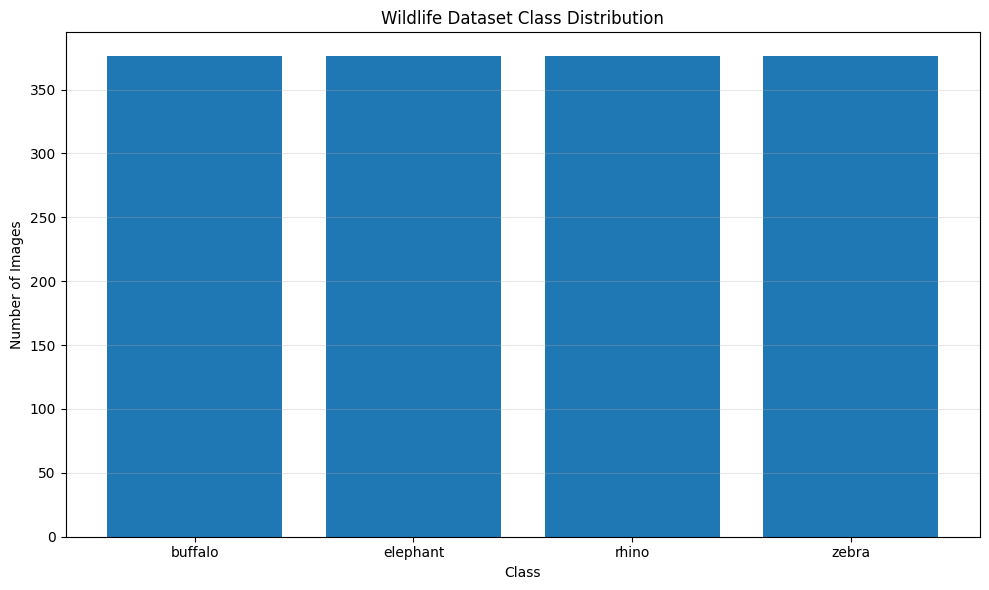

In [9]:
# ============================================================
# STEP 9 — DATASET DISTRIBUTION PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    dataset_counts.keys(),
    dataset_counts.values()
)

plt.title("Wildlife Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## STEP 10 — Check Corrupted Images

In [10]:
# ============================================================
# STEP 10 — CHECK CORRUPTED IMAGES
# ============================================================

bad_images = []

print("=" * 70)
print("CHECKING IMAGE FILES")
print("=" * 70)

for class_name in CLASS_NAMES:
    class_dir = DATA_ROOT / class_name

    image_paths = [
        p for p in class_dir.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    for image_path in image_paths:
        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            bad_images.append(image_path)

print(
    "Total corrupted/unreadable:",
    len(bad_images)
)

if bad_images:
    print("\nFirst 20 problematic files:")
    for path in bad_images[:20]:
        print(path)

    raise ValueError(
        "Corrupted images found. Fix/remove them before training."
    )

print("✅ No corrupted images found!")


CHECKING IMAGE FILES
Total corrupted/unreadable: 0
✅ No corrupted images found!


## STEP 11 — Training Configuration

In [11]:
# ============================================================
# STEP 11 — TRAINING CONFIGURATION
# ============================================================

IMG_SIZE = 384
BATCH_SIZE = 16
SEED = 42

VALIDATION_SPLIT = 0.20

HEAD_EPOCHS = 15
FINE_TUNE_EPOCHS = 35
TOTAL_EPOCHS = HEAD_EPOCHS + FINE_TUNE_EPOCHS

AUTOTUNE = tf.data.AUTOTUNE

MODEL_DIR = Path("/content/wildlife_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "wildlife_best.keras"

print("=" * 70)
print("WILDLIFE TRAINING CONFIGURATION")
print("=" * 70)
print("Classes          :", CLASS_NAMES)
print("Image size       :", IMG_SIZE)
print("Batch size       :", BATCH_SIZE)
print("Validation split :", VALIDATION_SPLIT)
print("Head epochs      :", HEAD_EPOCHS)
print("Fine-tune epochs :", FINE_TUNE_EPOCHS)
print("Total epochs     :", TOTAL_EPOCHS)
print("Model directory  :", MODEL_DIR)


WILDLIFE TRAINING CONFIGURATION
Classes          : ['buffalo', 'elephant', 'rhino', 'zebra']
Image size       : 384
Batch size       : 16
Validation split : 0.2
Head epochs      : 15
Fine-tune epochs : 35
Total epochs     : 50
Model directory  : /content/wildlife_models


## STEP 12 — Collect All Image Paths

In [12]:
# ============================================================
# STEP 12 — COLLECT ALL IMAGE PATHS
# ============================================================

all_image_paths = []
all_labels = []

print("=" * 70)
print("COLLECTING WILDLIFE IMAGES")
print("=" * 70)

for class_index, class_name in enumerate(CLASS_NAMES):
    class_dir = DATA_ROOT / class_name

    image_paths = [
        p for p in class_dir.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    print(
        f"{class_name:12s}: "
        f"{len(image_paths):,} images"
    )

    for image_path in image_paths:
        all_image_paths.append(str(image_path))
        all_labels.append(class_index)

all_image_paths = np.array(all_image_paths)
all_labels = np.array(all_labels)

print("\n" + "=" * 70)
print("TOTAL IMAGES:", len(all_image_paths))
print("Unique labels:", np.unique(all_labels))
print("=" * 70)

if len(np.unique(all_labels)) != NUM_CLASSES:
    raise ValueError(
        f"Expected labels [0,1,2,3], "
        f"but found {np.unique(all_labels)}"
    )


COLLECTING WILDLIFE IMAGES
buffalo     : 376 images
elephant    : 376 images
rhino       : 376 images
zebra       : 376 images

TOTAL IMAGES: 1504
Unique labels: [0 1 2 3]


## STEP 13 — Original Class Distribution

In [13]:
# ============================================================
# STEP 13 — ORIGINAL CLASS DISTRIBUTION
# ============================================================

print("=" * 70)
print("ORIGINAL DATASET DISTRIBUTION")
print("=" * 70)

for i, class_name in enumerate(CLASS_NAMES):
    count = np.sum(all_labels == i)
    percentage = count / len(all_labels) * 100

    print(
        f"{class_name:12s}: "
        f"{count:6,} images "
        f"({percentage:.2f}%)"
    )


ORIGINAL DATASET DISTRIBUTION
buffalo     :    376 images (25.00%)
elephant    :    376 images (25.00%)
rhino       :    376 images (25.00%)
zebra       :    376 images (25.00%)


## STEP 14 — Stratified Train / Validation Split

In [14]:
# ============================================================
# STEP 14 — STRATIFIED TRAIN / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

(
    train_paths,
    val_paths,
    train_labels,
    val_labels
) = train_test_split(
    all_image_paths,
    all_labels,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=all_labels
)

print("=" * 70)
print("STRATIFIED SPLIT CREATED")
print("=" * 70)

print("Training images  :", len(train_paths))
print("Validation images:", len(val_paths))


STRATIFIED SPLIT CREATED
Training images  : 1203
Validation images: 301


## STEP 15 — Verify Train / Validation Distribution

In [15]:
# ============================================================
# STEP 15 — VERIFY TRAIN / VALIDATION DISTRIBUTION
# ============================================================

print("=" * 70)
print("TRAINING DISTRIBUTION")
print("=" * 70)

for i, class_name in enumerate(CLASS_NAMES):
    count = np.sum(train_labels == i)
    print(f"{i} → {class_name:12s}: {count:,}")

print("\n" + "=" * 70)
print("VALIDATION DISTRIBUTION")
print("=" * 70)

for i, class_name in enumerate(CLASS_NAMES):
    count = np.sum(val_labels == i)
    print(f"{i} → {class_name:12s}: {count:,}")

for i, class_name in enumerate(CLASS_NAMES):
    if np.sum(val_labels == i) == 0:
        raise ValueError(
            f"{class_name} has ZERO validation images!"
        )

print("\n✅ All four classes are present in validation.")


TRAINING DISTRIBUTION
0 → buffalo     : 301
1 → elephant    : 301
2 → rhino       : 300
3 → zebra       : 301

VALIDATION DISTRIBUTION
0 → buffalo     : 75
1 → elephant    : 75
2 → rhino       : 76
3 → zebra       : 75

✅ All four classes are present in validation.


## STEP 16 — Image Loader

In [16]:
# ============================================================
# STEP 16 — IMAGE LOADER
# ============================================================

def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

print("✅ Image loader created")


✅ Image loader created


## STEP 17 — Create Fresh TensorFlow Datasets

In [17]:
# ============================================================
# STEP 17 — CREATE FRESH TF DATASETS
# ============================================================

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

train_ds = train_ds.shuffle(
    buffer_size=len(train_paths),
    seed=SEED,
    reshuffle_each_iteration=True
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

print("✅ Training dataset ready")
print("✅ Validation dataset ready")


✅ Training dataset ready
✅ Validation dataset ready


## STEP 18 — Final Validation Safety Check

In [18]:
# ============================================================
# STEP 18 — FINAL VALIDATION SAFETY CHECK
# ============================================================

validation_labels = []

for _, labels in val_ds:
    validation_labels.extend(labels.numpy())

validation_labels = np.array(validation_labels)

print("=" * 70)
print("FINAL VALIDATION CHECK")
print("=" * 70)

print("Total validation images:", len(validation_labels))
print()

for i, class_name in enumerate(CLASS_NAMES):
    count = np.sum(validation_labels == i)

    print(
        f"{i} → {class_name:12s}: "
        f"{count:,}"
    )

unique_labels = np.unique(validation_labels)

print("\nUnique labels:", unique_labels)

if len(unique_labels) != NUM_CLASSES:
    raise ValueError(
        f"Expected {NUM_CLASSES} classes, "
        f"but found {unique_labels}"
    )

print("\n✅ VALIDATION DATA IS CORRECT")
print("All four wildlife classes are present.")


FINAL VALIDATION CHECK
Total validation images: 301

0 → buffalo     : 75
1 → elephant    : 75
2 → rhino       : 76
3 → zebra       : 75

Unique labels: [0 1 2 3]

✅ VALIDATION DATA IS CORRECT
All four wildlife classes are present.


## STEP 19 — Class Weights

In [19]:
# ============================================================
# STEP 19 — CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights = {
    int(i): float(weight)
    for i, weight in enumerate(class_weights_array)
}

print("=" * 70)
print("CLASS WEIGHTS")
print("=" * 70)

for i, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_name:12s}: "
        f"{class_weights[i]:.4f}"
    )


CLASS WEIGHTS
buffalo     : 0.9992
elephant    : 0.9992
rhino       : 1.0025
zebra       : 0.9992


## STEP 20 — Data Augmentation

In [20]:
# ============================================================
# STEP 20 — DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.15, 0.20),
            width_factor=(-0.15, 0.20)
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08
        ),
        tf.keras.layers.RandomContrast(0.15),
        tf.keras.layers.RandomBrightness(0.15),
    ],
    name="wildlife_augmentation"
)

print("✅ Data augmentation ready")


✅ Data augmentation ready


## STEP 21 — Visualize Training Images

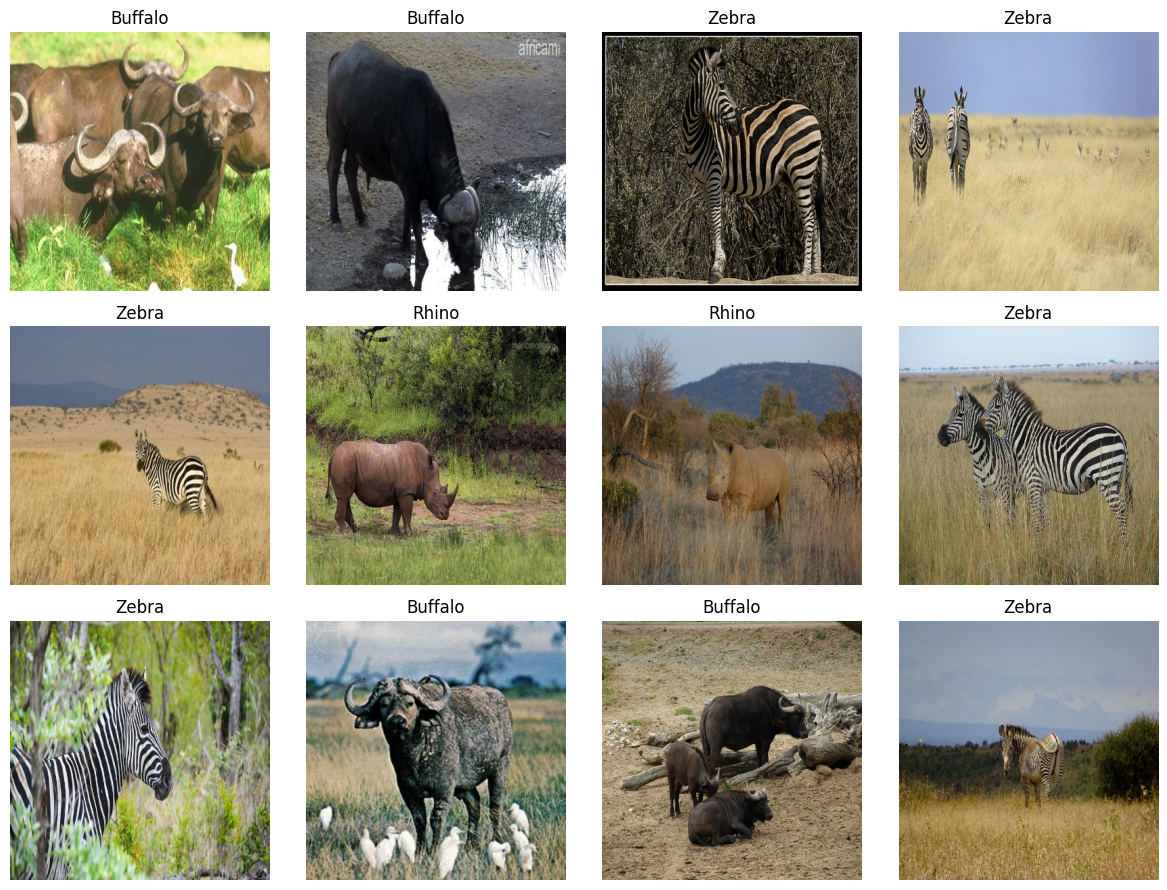

In [21]:
# ============================================================
# STEP 21 — VISUALIZE TRAINING IMAGES
# ============================================================

plt.figure(figsize=(12, 9))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            CLASS_NAMES[int(labels[i])].title()
        )

        plt.axis("off")

plt.tight_layout()
plt.show()


## STEP 22 — Build EfficientNetV2-S

In [22]:
# ============================================================
# STEP 22 — BUILD EFFICIENTNETV2-S
# ============================================================

base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling=None
)

base_model.trainable = False

inputs = tf.keras.layers.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dropout(0.35)(x)

x = tf.keras.layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Wildlife_EfficientNetV2S"
)

print("✅ EfficientNetV2-S created")
model.summary()


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetV2-S created


Model: "Wildlife_EfficientNetV2S"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ wildlife_augmentation           │ (None, 384, 384, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,666,468 (78.84 MB)

 Trainable params: 332,036 (1.27 MB)

 Non-trainable params: 20,334,432 (77.57 MB)

## STEP 23 — Compile Model

TensorFlow 2.20 in this Colab setup does not accept `label_smoothing` in `SparseCategoricalCrossentropy`, so it is intentionally not used.

In [23]:
# ============================================================
# STEP 23 — COMPILE MODEL
# ============================================================

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-3,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

print("✅ Model compiled")
print("Optimizer     : AdamW")
print("Learning rate : 1e-3")
print("Weight decay  : 1e-4")


✅ Model compiled
Optimizer     : AdamW
Learning rate : 1e-3
Weight decay  : 1e-4


## STEP 24 — Training Callbacks

In [24]:
# ============================================================
# STEP 24 — TRAINING CALLBACKS
# ============================================================

BEST_MODEL_PATH = MODEL_DIR / "wildlife_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        str(MODEL_DIR / "training_log.csv")
    )
]

print("✅ Callbacks ready")


✅ Callbacks ready


## STEP 25 — Phase 1 Training

In [25]:
# ============================================================
# STEP 25 — PHASE 1 TRAINING
# ============================================================

print("=" * 70)
print("PHASE 1 — TRAINING CLASSIFICATION HEAD")
print("=" * 70)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


PHASE 1 — TRAINING CLASSIFICATION HEAD
Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.8896 - loss: 0.3791
Epoch 1: val_accuracy improved from None to 0.98007, saving model to /content/wildlife_models/wildlife_best.keras

Epoch 1: finished saving model to /content/wildlife_models/wildlife_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 60s 409ms/step - accuracy: 0.9377 - loss: 0.2490 - val_accuracy: 0.9801 - val_loss: 0.1893 - learning_rate: 0.0010
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9749 - loss: 0.1476
Epoch 2: val_accuracy did not improve from 0.98007
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 309ms/step - accuracy: 0.9667 - loss: 0.1794 - val_accuracy: 0.9801 - val_loss: 0.1526 - learning_rate: 0.0010
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9705 - loss: 0.1392
Epoch 3: val_accuracy did not improve from 0.98007
76/76 ━━━━━━━━━━━━━━━━━━━━ 42s 324ms/step - accuracy: 0.9659 - loss: 0.1508 - val_accuracy: 0.9801 - val_loss: 0.1312 - lea

## STEP 26 — Phase 1 Curves

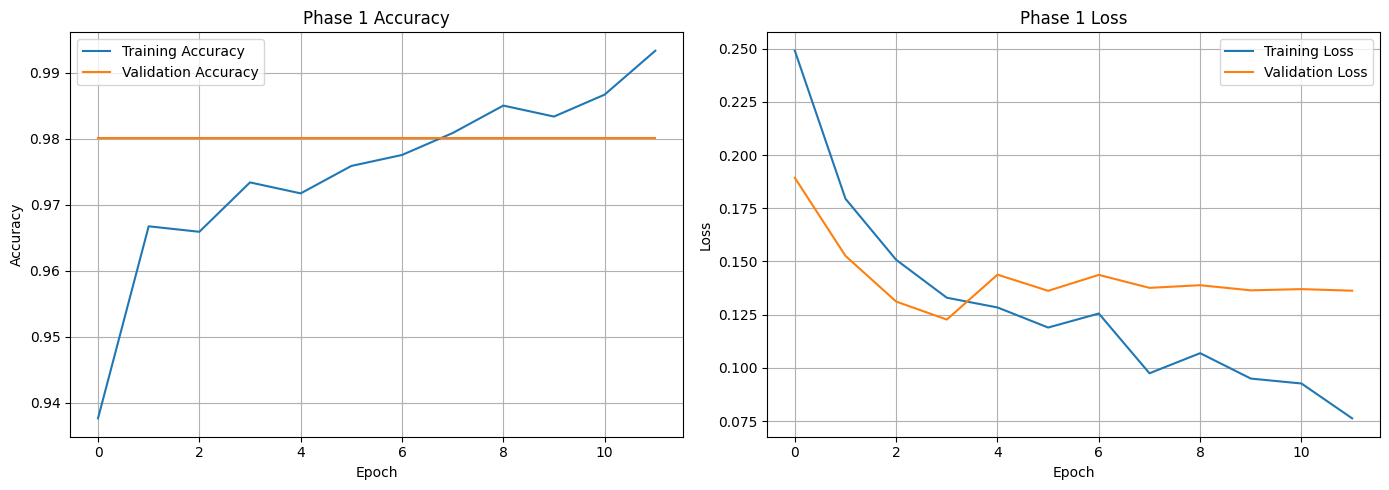

In [26]:
# ============================================================
# STEP 26 — PHASE 1 TRAINING CURVES
# ============================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history_head.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_head.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Phase 1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(
    history_head.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_head.history["val_loss"],
    label="Validation Loss"
)

plt.title("Phase 1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## STEP 27 — Prepare Fine-Tuning

In [27]:
# ============================================================
# STEP 27 — PREPARE FINE-TUNING
# ============================================================

base_model.trainable = True

fine_tune_from = int(
    len(base_model.layers) * 0.60
)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True

# Keep BatchNormalization layers frozen for stable fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(
    1 for layer in base_model.layers
    if layer.trainable
)

print(
    "Trainable backbone layers:",
    trainable_layers
)


Trainable backbone layers: 165


## STEP 28 — Recompile for Fine-Tuning

In [28]:
# ============================================================
# STEP 28 — RECOMPILE FOR FINE-TUNING
# ============================================================

fine_optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-5,
    weight_decay=1e-5
)

model.compile(
    optimizer=fine_optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=["accuracy"]
)

print("✅ Fine-tuning model compiled")
print("Learning rate: 1e-5")
print("Weight decay : 1e-5")


✅ Fine-tuning model compiled
Learning rate: 1e-5
Weight decay : 1e-5


## STEP 29 — Phase 2 Fine-Tuning

In [29]:
# ============================================================
# STEP 29 — PHASE 2 FINE-TUNING
# ============================================================

print("=" * 70)
print("PHASE 2 — FINE-TUNING")
print("=" * 70)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=len(history_head.history["loss"]),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


PHASE 2 — FINE-TUNING
Epoch 13/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9812 - loss: 0.1174
Epoch 13: val_accuracy did not improve from 0.98007
76/76 ━━━━━━━━━━━━━━━━━━━━ 73s 480ms/step - accuracy: 0.9817 - loss: 0.1135 - val_accuracy: 0.9801 - val_loss: 0.1372 - learning_rate: 1.0000e-05
Epoch 14/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9863 - loss: 0.0908
Epoch 14: val_accuracy did not improve from 0.98007
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 416ms/step - accuracy: 0.9842 - loss: 0.0968 - val_accuracy: 0.9801 - val_loss: 0.1415 - learning_rate: 1.0000e-05
Epoch 15/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9892 - loss: 0.0754
Epoch 15: val_accuracy did not improve from 0.98007

Epoch 15: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
76/76 ━━━━━━━━━━━━━━━━━━━━ 31s 408ms/step - accuracy: 0.9884 - loss: 0.0829 - val_accuracy: 0.9801 - val_loss: 0.1482 - learning_rate: 1.0000e-05
Epoch 16/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 35

## STEP 30 — Combined Training Curves

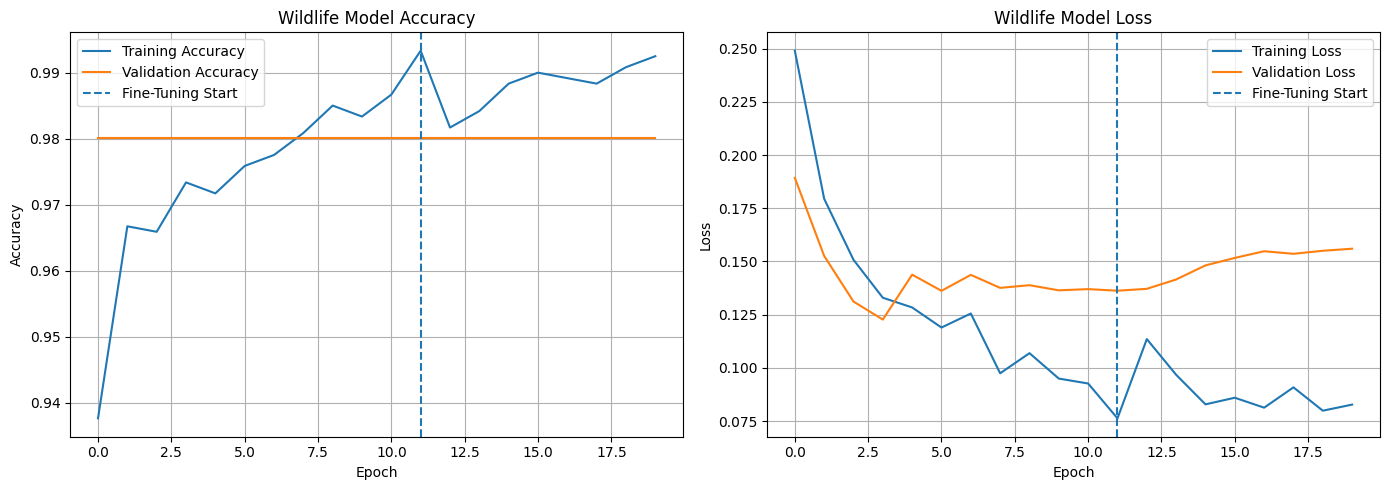

In [30]:
# ============================================================
# STEP 30 — COMBINED TRAINING CURVES
# ============================================================

combined_history = {}

for key in history_head.history:
    combined_history[key] = (
        history_head.history[key]
        + history_fine.history[key]
    )

fine_start = len(history_head.history["accuracy"])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    combined_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    combined_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    fine_start - 1,
    linestyle="--",
    label="Fine-Tuning Start"
)

plt.title("Wildlife Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(
    combined_history["loss"],
    label="Training Loss"
)

plt.plot(
    combined_history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    fine_start - 1,
    linestyle="--",
    label="Fine-Tuning Start"
)

plt.title("Wildlife Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## STEP 31 — Load Best Model

In [31]:
# ============================================================
# STEP 31 — LOAD BEST MODEL
# ============================================================

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print("✅ Best model loaded")
print("Path:", BEST_MODEL_PATH)


✅ Best model loaded
Path: /content/wildlife_models/wildlife_best.keras


## STEP 32 — Final Validation

In [32]:
# ============================================================
# STEP 32 — FINAL VALIDATION
# ============================================================

val_loss, val_accuracy = best_model.evaluate(
    val_ds,
    verbose=1
)

print("\n" + "=" * 70)
print("FINAL VALIDATION RESULTS")
print("=" * 70)

print(
    f"Validation Loss     : {val_loss:.5f}"
)

print(
    f"Validation Accuracy : {val_accuracy * 100:.2f}%"
)

print("=" * 70)


19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 204ms/step - accuracy: 0.9801 - loss: 0.1893

FINAL VALIDATION RESULTS
Validation Loss     : 0.18928
Validation Accuracy : 98.01%


## STEP 33 — Generate Predictions

In [33]:
# ============================================================
# STEP 33 — GENERATE VALIDATION PREDICTIONS
# ============================================================

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    predictions = best_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("✅ Predictions generated")
print("Validation samples:", len(y_true))
print("Actual classes:", np.unique(y_true))


✅ Predictions generated
Validation samples: 301
Actual classes: [0 1 2 3]


## STEP 34 — Final Class Distribution

In [34]:
# ============================================================
# STEP 34 — FINAL CLASS DISTRIBUTION
# ============================================================

print("=" * 70)
print("FINAL CLASS DISTRIBUTION")
print("=" * 70)

for i, class_name in enumerate(CLASS_NAMES):
    true_count = np.sum(y_true == i)
    pred_count = np.sum(y_pred == i)

    print(
        f"{class_name:12s} | "
        f"Actual: {true_count:5d} | "
        f"Predicted: {pred_count:5d}"
    )

if len(np.unique(y_true)) != NUM_CLASSES:
    raise ValueError(
        "Final validation predictions do not contain all four classes."
    )

print("\n✅ All four classes confirmed.")


FINAL CLASS DISTRIBUTION
buffalo      | Actual:    75 | Predicted:    74
elephant     | Actual:    75 | Predicted:    80
rhino        | Actual:    76 | Predicted:    74
zebra        | Actual:    75 | Predicted:    73

✅ All four classes confirmed.


## STEP 35 — Accuracy / Precision / Recall / F1

In [35]:
# ============================================================
# STEP 35 — FINAL METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n" + "=" * 70)
print("🦓 WILDLIFE CLASSIFIER — FINAL METRICS")
print("=" * 70)

print(f"Accuracy        : {accuracy * 100:.2f}%")
print(f"Precision       : {precision * 100:.2f}%")
print(f"Recall          : {recall * 100:.2f}%")
print(f"F1 Score        : {f1 * 100:.2f}%")
print(f"Validation Loss : {val_loss:.5f}")

print("=" * 70)



🦓 WILDLIFE CLASSIFIER — FINAL METRICS
Accuracy        : 98.01%
Precision       : 98.11%
Recall          : 98.01%
F1 Score        : 98.02%
Validation Loss : 0.18928


## STEP 36 — Classification Report

In [36]:
# ============================================================
# STEP 36 — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print("=" * 70)
print("🦓 CLASSIFICATION REPORT")
print("=" * 70)
print(report)


🦓 CLASSIFICATION REPORT
              precision    recall  f1-score   support

     buffalo     0.9865    0.9733    0.9799        75
    elephant     0.9375    1.0000    0.9677        75
       rhino     1.0000    0.9737    0.9867        76
       zebra     1.0000    0.9733    0.9865        75

    accuracy                         0.9801       301
   macro avg     0.9810    0.9801    0.9802       301
weighted avg     0.9811    0.9801    0.9802       301



## STEP 37 — Confusion Matrix

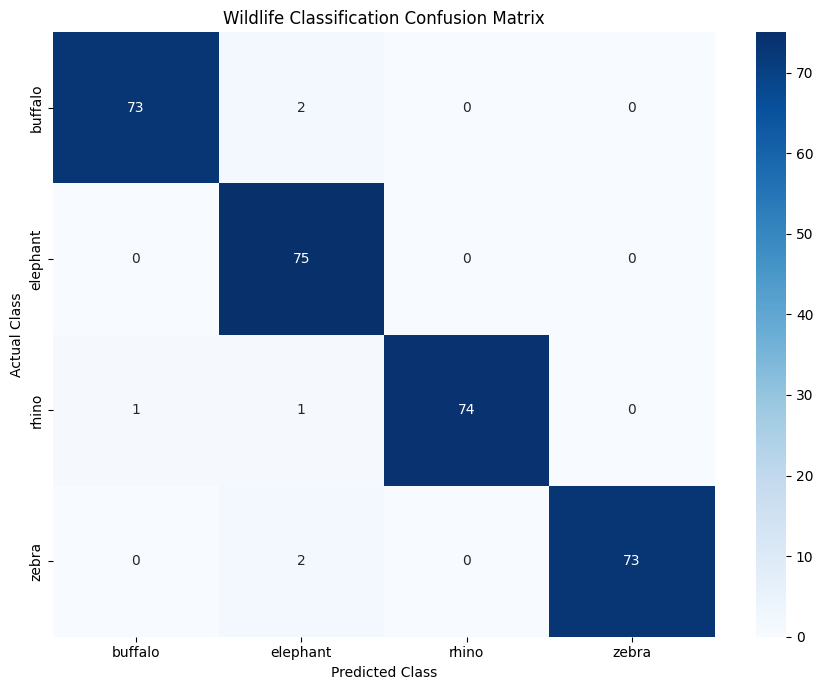

In [37]:
# ============================================================
# STEP 37 — CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Wildlife Classification Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()


## STEP 38 — Per-Class Performance

In [38]:
# ============================================================
# STEP 38 — PER-CLASS PERFORMANCE
# ============================================================

class_report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(class_report).T

metrics_df = metrics_df[
    ["precision", "recall", "f1-score", "support"]
]

display(metrics_df)


,precision,recall,f1-score,support
buffalo,0.986486,0.973333,0.979866,75.000000
elephant,0.937500,1.000000,0.967742,75.000000
rhino,1.000000,0.973684,0.986667,76.000000
zebra,1.000000,0.973333,0.986486,75.000000
accuracy,0.980066,0.980066,0.980066,0.980066
macro avg,0.980997,0.980088,0.980190,301.000000
weighted avg,0.981060,0.980066,0.980212,301.000000


## STEP 39 — Find Misclassified Images

In [39]:
# ============================================================
# STEP 39 — FIND MISCLASSIFIED IMAGES
# ============================================================

wrong_indices = np.where(
    y_true != y_pred
)[0]

print("=" * 70)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 70)

print("Total validation images:", len(y_true))
print("Correct predictions:", np.sum(y_true == y_pred))
print("Incorrect predictions:", len(wrong_indices))

print(
    "Error rate:",
    f"{len(wrong_indices) / len(y_true) * 100:.2f}%"
)

print("=" * 70)


MISCLASSIFICATION ANALYSIS
Total validation images: 301
Correct predictions: 295
Incorrect predictions: 6
Error rate: 1.99%


## STEP 40 — Visualize Misclassified Images

/tmp/ipykernel_3104/813368298.py:47: UserWarning: Glyph 129427 (\N{ZEBRA FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129427 (\N{ZEBRA FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


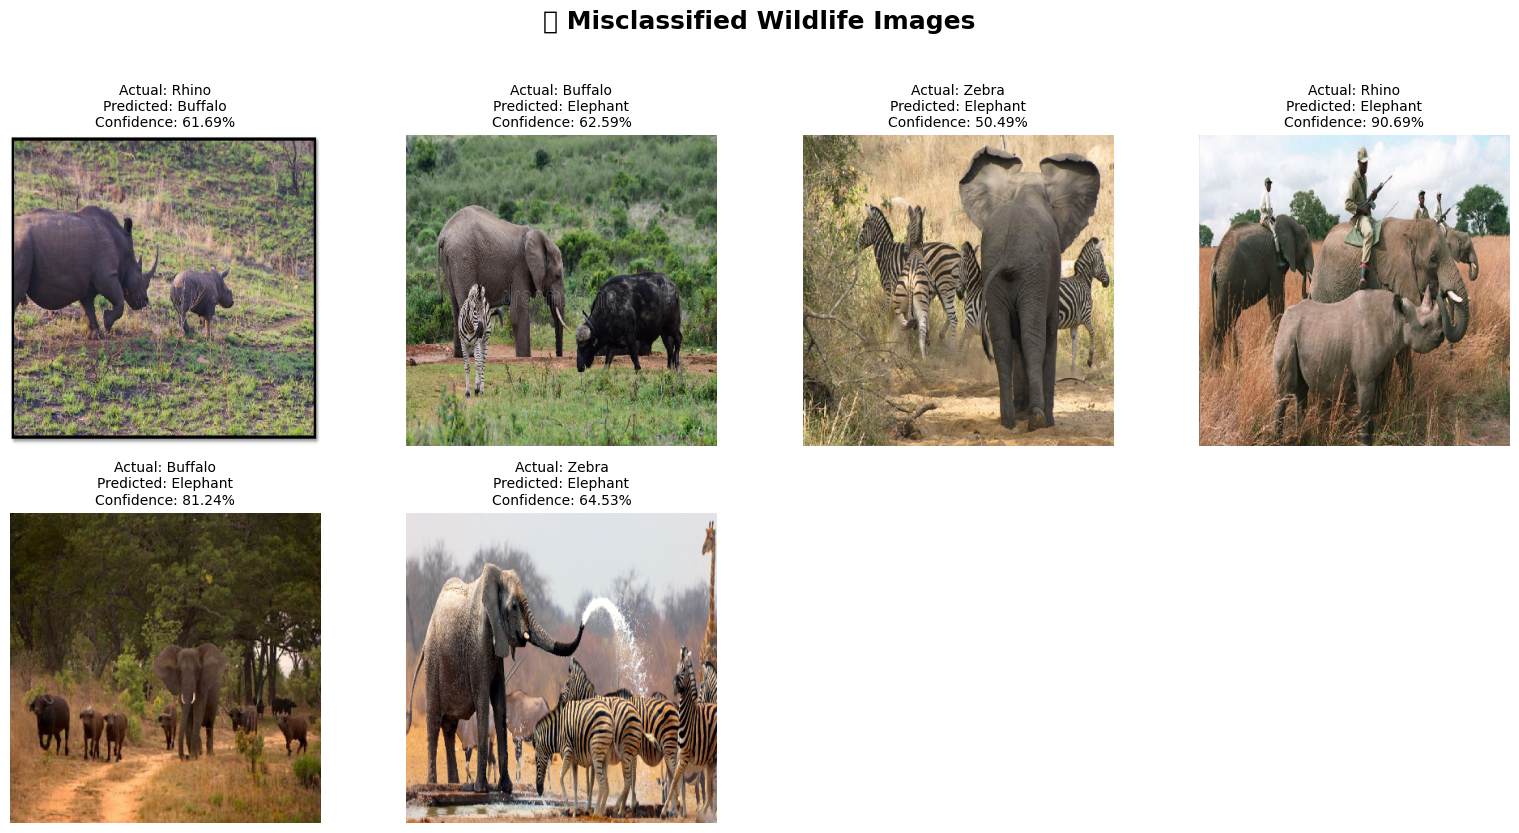

In [40]:
# ============================================================
# STEP 40 — VISUALIZE MISCLASSIFIED IMAGES
# ============================================================

if len(wrong_indices) == 0:
    print("🎉 No misclassified images!")
else:
    NUM_TO_SHOW = min(20, len(wrong_indices))

    selected_indices = wrong_indices[:NUM_TO_SHOW]

    plt.figure(figsize=(16, 20))

    for plot_number, idx in enumerate(selected_indices):
        image_path = val_paths[idx]

        image = tf.keras.utils.load_img(
            image_path,
            target_size=(IMG_SIZE, IMG_SIZE)
        )

        plt.subplot(5, 4, plot_number + 1)
        plt.imshow(image)

        actual_class = CLASS_NAMES[int(y_true[idx])]
        predicted_class = CLASS_NAMES[int(y_pred[idx])]

        confidence = (
            y_prob[idx][y_pred[idx]] * 100
        )

        plt.title(
            f"Actual: {actual_class.title()}\n"
            f"Predicted: {predicted_class.title()}\n"
            f"Confidence: {confidence:.2f}%",
            fontsize=10
        )

        plt.axis("off")

    plt.suptitle(
        "🦓 Misclassified Wildlife Images",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


## STEP 41 — Misclassification Pairs

In [41]:
# ============================================================
# STEP 41 — MISCLASSIFICATION PAIRS
# ============================================================

from collections import Counter

misclassification_pairs = Counter()

for idx in wrong_indices:
    actual = CLASS_NAMES[int(y_true[idx])]
    predicted = CLASS_NAMES[int(y_pred[idx])]

    misclassification_pairs[
        (actual, predicted)
    ] += 1

print("=" * 70)
print("MISCLASSIFICATION PAIRS")
print("=" * 70)

if not misclassification_pairs:
    print("🎉 No misclassifications!")
else:
    for (actual, predicted), count in (
        misclassification_pairs.most_common()
    ):
        print(
            f"{actual.title():12s} → "
            f"{predicted.title():12s} : "
            f"{count} images"
        )


MISCLASSIFICATION PAIRS
Buffalo      → Elephant     : 2 images
Zebra        → Elephant     : 2 images
Rhino        → Buffalo      : 1 images
Rhino        → Elephant     : 1 images


## STEP 42 — Save Final Model

In [42]:
# ============================================================
# STEP 42 — SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_PATH = (
    MODEL_DIR /
    "wildlife_classifier_final.keras"
)

best_model.save(FINAL_MODEL_PATH)

print("✅ Model saved:")
print(FINAL_MODEL_PATH)

print(
    "Model size:",
    round(
        FINAL_MODEL_PATH.stat().st_size / (1024 * 1024),
        2
    ),
    "MB"
)


✅ Model saved:
/content/wildlife_models/wildlife_classifier_final.keras
Model size: 83.1 MB


## STEP 43 — Save Class Names

In [43]:
# ============================================================
# STEP 43 — SAVE CLASS NAMES
# ============================================================

CLASS_NAMES_PATH = (
    MODEL_DIR /
    "class_names.json"
)

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(CLASS_NAMES, f, indent=4)

print("✅ Class names saved:")
print(CLASS_NAMES_PATH)


✅ Class names saved:
/content/wildlife_models/class_names.json


## STEP 44 — Save Final Metrics

In [44]:
# ============================================================
# STEP 44 — SAVE FINAL METRICS
# ============================================================

FINAL_METRICS = {
    "validation_loss": float(val_loss),
    "accuracy": float(accuracy),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_weighted": float(f1),
    "classes": CLASS_NAMES
}

METRICS_PATH = (
    MODEL_DIR /
    "final_metrics.json"
)

with open(METRICS_PATH, "w") as f:
    json.dump(FINAL_METRICS, f, indent=4)

print("✅ Metrics saved:")
print(METRICS_PATH)


✅ Metrics saved:
/content/wildlife_models/final_metrics.json


## STEP 45 — Save Training History

In [45]:
# ============================================================
# STEP 45 — Save Training History
# ============================================================

HISTORY_PATH = (
    MODEL_DIR /
    "training_history.json"
)

with open(HISTORY_PATH, "w") as f:
    json.dump(combined_history, f, indent=4)

print("✅ Training history saved:")
print(HISTORY_PATH)


✅ Training history saved:
/content/wildlife_models/training_history.json


## STEP 46 — Single Image Prediction

Saving 034.jpg to 034.jpg

🦓 WILDLIFE PREDICTION
Predicted Animal : Rhino
Confidence       : 85.20%

All predictions:
rhino       : 85.20%
buffalo     : 11.06%
zebra       : 2.62%
elephant    : 1.11%


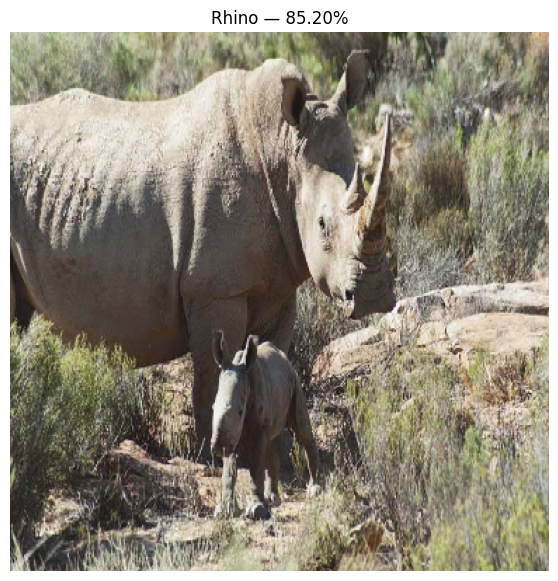

In [46]:
# ============================================================
# STEP 46 — SINGLE IMAGE PREDICTION
# ============================================================

from google.colab import files

uploaded = files.upload()

for filename in uploaded:
    image_path = Path("/content") / filename

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    image_array = tf.keras.utils.img_to_array(image)

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    prediction = best_model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    confidence = (
        prediction[predicted_index] * 100
    )

    print("\n" + "=" * 70)
    print("🦓 WILDLIFE PREDICTION")
    print("=" * 70)

    print(
        f"Predicted Animal : "
        f"{predicted_class.title()}"
    )

    print(
        f"Confidence       : "
        f"{confidence:.2f}%"
    )

    print("\nAll predictions:")

    for index in np.argsort(prediction)[::-1]:
        print(
            f"{CLASS_NAMES[index]:12s}: "
            f"{prediction[index] * 100:.2f}%"
        )

    print("=" * 70)

    plt.figure(figsize=(7, 7))
    plt.imshow(image)

    plt.title(
        f"{predicted_class.title()} — "
        f"{confidence:.2f}%"
    )

    plt.axis("off")
    plt.show()


## STEP 47 — Package Model Files

In [47]:
# ============================================================
# STEP 47 — CREATE MODEL PACKAGE
# ============================================================

PACKAGE_DIR = Path(
    "/content/wildlife_model_package"
)

if PACKAGE_DIR.exists():
    shutil.rmtree(PACKAGE_DIR)

PACKAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for file in MODEL_DIR.iterdir():
    if file.is_file():
        shutil.copy2(
            file,
            PACKAGE_DIR
        )

PACKAGE_BASE = "/content/wildlife_model_package"

PACKAGE_ZIP = shutil.make_archive(
    PACKAGE_BASE,
    "zip",
    PACKAGE_DIR
)

print("✅ Model package created:")
print(PACKAGE_ZIP)


✅ Model package created:
/content/wildlife_model_package.zip


## STEP 48 — Download Model Package to PC

In [48]:
# ============================================================
# STEP 48 — DOWNLOAD MODEL PACKAGE
# ============================================================

from google.colab import files

files.download(
    "/content/wildlife_model_package.zip"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>